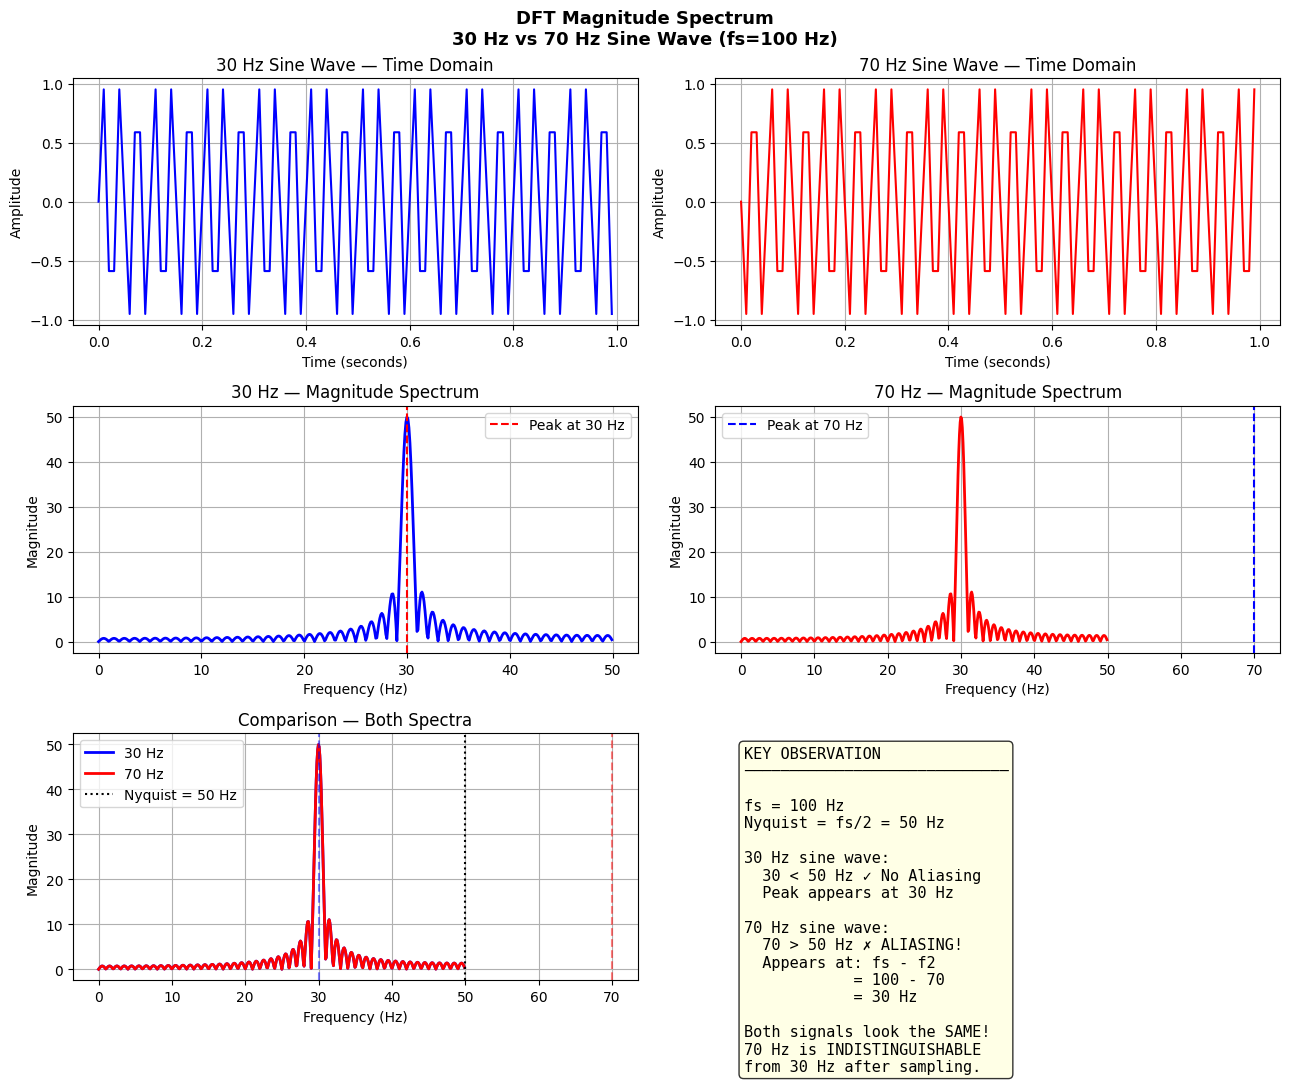

Sampling frequency  fs = 100 Hz
Nyquist frequency      = 50 Hz
Signal 1: f1 = 30 Hz → 30 < 50 → No Aliasing ✓
Signal 2: f2 = 70 Hz → 70 > 50 → ALIASING! ✗
70 Hz appears as: 100 - 70 = 30 Hz


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# GIVEN PARAMETERS
# =========================
fs = 100       # Sampling frequency (Hz)
T  = 1         # Duration (seconds)
n  = np.arange(0, T * fs)   # n = [0, 1, 2, ... 99]  → 100 samples

# =========================
# STEP 1: GENERATE SIGNALS
# =========================
f1 = 30   # 30 Hz sine wave
f2 = 70   # 70 Hz sine wave

x1 = np.sin(2 * np.pi * f1 * n / fs)   # 30 Hz signal
x2 = np.sin(2 * np.pi * f2 * n / fs)   # 70 Hz signal

# =========================
# STEP 2: MANUAL DFT
# H(k) = Σ x(n) * e^(-j2πkn/N)
# =========================
N    = len(n)     # = 100
NFFT = 1024       # smooth plot

H1 = np.zeros(NFFT, dtype=complex)
H2 = np.zeros(NFFT, dtype=complex)

for k in range(NFFT):
    for i in range(N):
        H1[k] += x1[i] * np.exp(-1j * 2 * np.pi * k * i / NFFT)
        H2[k] += x2[i] * np.exp(-1j * 2 * np.pi * k * i / NFFT)

# =========================
# STEP 3: MAGNITUDE SPECTRUM
# Take only first half (0 to fs/2)
# =========================
half = NFFT // 2

mag1 = np.abs(H1[:half])
mag2 = np.abs(H2[:half])

freq = np.arange(half) * fs / NFFT    # frequency axis in Hz

# =========================
# STEP 4: PLOT
# =========================
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
fig.suptitle("DFT Magnitude Spectrum\n30 Hz vs 70 Hz Sine Wave (fs=100 Hz)",
             fontsize=13, fontweight='bold')

# --- Row 1: Time Domain Signals ---
axes[0][0].plot(n / fs, x1, 'b-', linewidth=1.5)
axes[0][0].set_title("30 Hz Sine Wave — Time Domain")
axes[0][0].set_xlabel("Time (seconds)")
axes[0][0].set_ylabel("Amplitude")
axes[0][0].grid(True)

axes[0][1].plot(n / fs, x2, 'r-', linewidth=1.5)
axes[0][1].set_title("70 Hz Sine Wave — Time Domain")
axes[0][1].set_xlabel("Time (seconds)")
axes[0][1].set_ylabel("Amplitude")
axes[0][1].grid(True)

# --- Row 2: Magnitude Spectrum ---
axes[1][0].plot(freq, mag1, 'b-', linewidth=2)
axes[1][0].axvline(f1, color='r', linestyle='--', label=f'Peak at {f1} Hz')
axes[1][0].set_title("30 Hz — Magnitude Spectrum")
axes[1][0].set_xlabel("Frequency (Hz)")
axes[1][0].set_ylabel("Magnitude")
axes[1][0].legend()
axes[1][0].grid(True)

axes[1][1].plot(freq, mag2, 'r-', linewidth=2)
axes[1][1].axvline(f2, color='b', linestyle='--', label=f'Peak at {f2} Hz')
axes[1][1].set_title("70 Hz — Magnitude Spectrum")
axes[1][1].set_xlabel("Frequency (Hz)")
axes[1][1].set_ylabel("Magnitude")
axes[1][1].legend()
axes[1][1].grid(True)

# --- Row 3: Both Spectra Together ---
axes[2][0].plot(freq, mag1, 'b-', linewidth=2, label='30 Hz')
axes[2][0].plot(freq, mag2, 'r-', linewidth=2, label='70 Hz')
axes[2][0].axvline(f1, color='b', linestyle='--', alpha=0.5)
axes[2][0].axvline(f2, color='r', linestyle='--', alpha=0.5)
axes[2][0].axvline(fs/2, color='k', linestyle=':', label=f'Nyquist = {int(fs/2)} Hz')
axes[2][0].set_title("Comparison — Both Spectra")
axes[2][0].set_xlabel("Frequency (Hz)")
axes[2][0].set_ylabel("Magnitude")
axes[2][0].legend()
axes[2][0].grid(True)

# --- Row 3 Right: Aliasing Explanation ---
axes[2][1].axis('off')
axes[2][1].text(0.05, 0.95,
    "KEY OBSERVATION\n"
    "─────────────────────────────\n\n"
    "fs = 100 Hz\n"
    "Nyquist = fs/2 = 50 Hz\n\n"
    "30 Hz sine wave:\n"
    "  30 < 50 Hz ✓ No Aliasing\n"
    "  Peak appears at 30 Hz\n\n"
    "70 Hz sine wave:\n"
    "  70 > 50 Hz ✗ ALIASING!\n"
    "  Appears at: fs - f2\n"
    "            = 100 - 70\n"
    "            = 30 Hz\n\n"
    "Both signals look the SAME!\n"
    "70 Hz is INDISTINGUISHABLE\n"
    "from 30 Hz after sampling.",
    transform=axes[2][1].transAxes,
    fontsize=11,
    verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()
plt.show()

# =========================
# PRINT SUMMARY
# =========================
print("=" * 40)
print(f"Sampling frequency  fs = {fs} Hz")
print(f"Nyquist frequency      = {fs//2} Hz")
print("=" * 40)
print(f"Signal 1: f1 = {f1} Hz → {f1} < {fs//2} → No Aliasing ✓")
print(f"Signal 2: f2 = {f2} Hz → {f2} > {fs//2} → ALIASING! ✗")
print(f"70 Hz appears as: {fs} - {f2} = {fs-f2} Hz")
print("=" * 40)